In [77]:
import cv2
from matplotlib.pyplot import gray
import numpy as np
import glob

CHECKERBOARD = (9, 6) 
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,30,0.001)

In [79]:
objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)

objpoints = []
imgpoints = []
images = glob.glob("C:/Users/hp/onboarding-opencv/raw-captures/task10/*.jpg")
print("Images found:", len(images))

successful = 0
discarded = 0
image_size = None

Images found: 10


In [81]:
for fname in images:

    img = cv2.imread(fname)
    if img is None:
        print("Could not read:", fname)
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if image_size is None:
        image_size = gray.shape[::-1]
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, None)

    if ret:

        successful += 1
        objpoints.append(objp)

        corners2 = cv2.cornerSubPix(gray,corners,(11,11),(-1,-1),criteria)
        imgpoints.append(corners2)

        cv2.drawChessboardCorners(img,CHECKERBOARD,corners2,ret)
        cv2.imshow("Detected Corners", img)
        cv2.waitKey(200)

    else:
        discarded += 1
        print("Discarded:", fname)

if successful == 0:
    raise RuntimeError("No checkerboard corners were detected.")
cv2.destroyAllWindows()

In [85]:
ret, cameraMatrix, distCoeffs, rvecs, tvecs = cv2.calibrateCamera(objpoints,imgpoints,gray.shape[::-1],None,None)

print("Camera Matrix")
print(cameraMatrix)
mean_error = 0

fx = cameraMatrix[0, 0]
fy = cameraMatrix[1, 1]
cx = cameraMatrix[0, 2]
cy = cameraMatrix[1, 2]

print("\nCamera Parameters")
print("------------------------")
print(f"fx (Focal Length X)     : {fx:.4f}")
print(f"fy (Focal Length Y)     : {fy:.4f}")
print(f"cx (Principal Point X)  : {cx:.4f}")
print(f"cy (Principal Point Y)  : {cy:.4f}")

print("\nDistortion Coefficients")
print("------------------------")
print(distCoeffs)

Camera Matrix
[[3.35790842e+03 0.00000000e+00 2.36088970e+03]
 [0.00000000e+00 3.33129877e+03 1.51796486e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Camera Parameters
------------------------
fx (Focal Length X)     : 3357.9084
fy (Focal Length Y)     : 3331.2988
cx (Principal Point X)  : 2360.8897
cy (Principal Point Y)  : 1517.9649

Distortion Coefficients
------------------------
[[ 0.25357478 -0.75260593  0.00611104  0.00257418  0.64082039]]


In [67]:
for i in range(len(objpoints)):

    imgpoints2, _ = cv2.projectPoints(objpoints[i],rvecs[i],tvecs[i],cameraMatrix,distCoeffs)

    error = cv2.norm(imgpoints[i],imgpoints2,cv2.NORM_L2) / len(imgpoints2)

    mean_error += error

mean_error /= len(objpoints)
print("\nReprojection Error =", mean_error)


Reprojection Error = 0.3492790879901371


4608


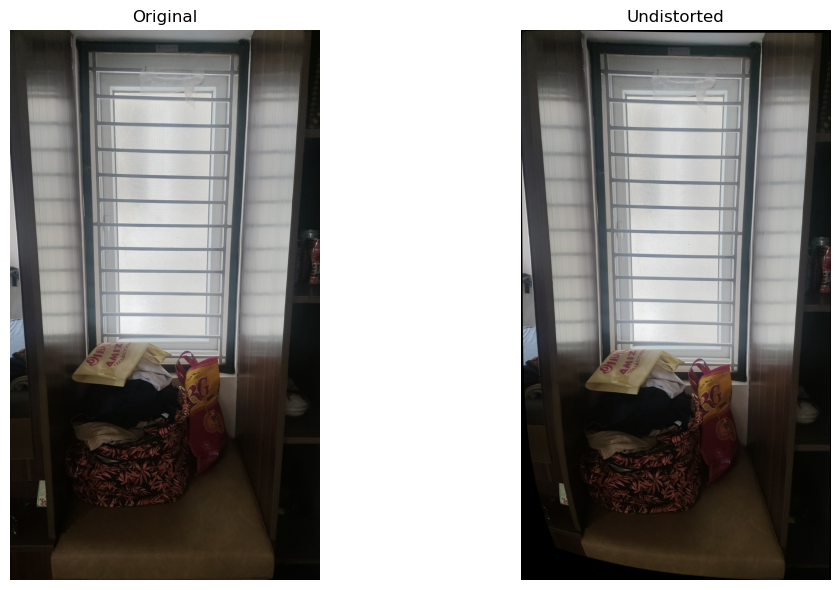

In [68]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("C:/Users/hp/onboarding-opencv/raw-captures/task10.jpg")
print(len(img))
h, w = img.shape[:2]

newCameraMatrix, roi = cv2.getOptimalNewCameraMatrix(cameraMatrix,distCoeffs,(w, h),1,(w, h))

undistorted = cv2.undistort(img,cameraMatrix,distCoeffs,None,newCameraMatrix)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
undist_rgb = cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(undist_rgb)
plt.title("Undistorted")
plt.axis("off")

plt.tight_layout()
plt.show()